# Movie recommendation with Naive Bayes

## Load data, explore data, train model, evaluate

In [1]:
import os
import json
import requests
import zipfile
import numpy as np
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

In [2]:
def download_and_extract_zip(zip_path, extract_dir, url):
    if not os.path.exists(extract_dir):
        if not os.path.exists(zip_path):
            print(f"Downloading from {url}...")
            response = requests.get(url, timeout=60)
            response.raise_for_status()
            with open(zip_path, "wb") as f:
                f.write(response.content)
            print("Download complete.")
        
        print("Extracting zip...")
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(extract_dir)
        print("Extraction complete.")
    
    return extract_dir

In [3]:
def load_rating_data(data_path, n_users, n_movies):
    data = np.zeros([n_users, n_movies], dtype=np.float32)
    movie_id_mapping = {}
    movie_n_rating = defaultdict(int)

    with open(data_path, 'r') as file:
        for line in file.readlines()[1:]:  # skip header
            user_id, movie_id, rating, _ = line.strip().split(",")
            user_id = int(user_id) - 1
            if movie_id not in movie_id_mapping:
                movie_id_mapping[movie_id] = len(movie_id_mapping)
            rating = round(float(rating))  # rounds 0.5→1, 1.5→2
            data[user_id, movie_id_mapping[movie_id]] = rating
            if rating > 0:
                movie_n_rating[movie_id] += 1

    return data, movie_n_rating, movie_id_mapping

In [4]:
URL = "http://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
ZIP_PATH = "ml-latest-small.zip"
EXTRACT_DIR = "ml-latest-small"
RATINGS_PATH = os.path.join(EXTRACT_DIR, "ml-latest-small", "ratings.csv")

download_and_extract_zip(ZIP_PATH, EXTRACT_DIR, URL)

'ml-latest-small'

In [5]:
n_users = 610
n_movies = 9724
data, movie_n_rating, movie_id_mapping = load_rating_data(RATINGS_PATH, n_users, n_movies)

In [6]:
def display_distribution(data):
    values, counts = np.unique(data, return_counts=True)
    for value, count in zip(values, counts):
        print(f'Number of rating {int(value)}: {count}')

In [7]:
display_distribution(data)

Number of rating 0: 5832174
Number of rating 1: 2811
Number of rating 2: 14892
Number of rating 3: 20047
Number of rating 4: 48505
Number of rating 5: 13211


In [8]:
movie_id_most, n_rating_most = sorted(movie_n_rating.items(), key=lambda d: d[1], reverse=True)[0]
print(f'Movie ID {movie_id_most} has {n_rating_most} ratings.')

Movie ID 356 has 328 ratings.


In [9]:
X_raw = np.delete(data, movie_id_mapping[movie_id_most], axis=1)
Y_raw = data[:, movie_id_mapping[movie_id_most]]
X = X_raw[Y_raw > 0]
Y = Y_raw[Y_raw > 0]

In [10]:
print('Shape of X:', X.shape)
print('Shape of Y:', Y.shape)

Shape of X: (328, 9723)
Shape of Y: (328,)


In [11]:
display_distribution(Y)

Number of rating 1: 1
Number of rating 2: 12
Number of rating 3: 39
Number of rating 4: 160
Number of rating 5: 116


In [12]:
recommend = 3
Y[Y <= recommend] = 0
Y[Y > recommend] = 1

In [13]:
n_pos = (Y == 1).sum()
n_neg = (Y == 0).sum()
print(f'{n_pos} positive samples and {n_neg} negative samples.')

276 positive samples and 52 negative samples.


In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [15]:
print(len(Y_train), len(Y_test))

262 66


In [16]:
clf = MultinomialNB(alpha=1.0, fit_prior=True)
clf.fit(X_train, Y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [17]:
prediction_prob = clf.predict_proba(X_test)
print(prediction_prob[0:10])

[[3.13187999e-17 1.00000000e+00]
 [1.00000000e+00 1.31327951e-43]
 [1.60922661e-28 1.00000000e+00]
 [1.21704032e-47 1.00000000e+00]
 [5.06936193e-14 1.00000000e+00]
 [1.53692143e-61 1.00000000e+00]
 [2.44791425e-69 1.00000000e+00]
 [1.35145843e-80 1.00000000e+00]
 [1.00000000e+00 2.21384313e-17]
 [1.00000000e+00 6.88499180e-23]]


In [18]:
prediction = clf.predict(X_test)
print(prediction[:10])

[1. 0. 1. 1. 1. 1. 1. 1. 0. 0.]


In [19]:
accuracy = clf.score(X_test, Y_test)
print(f'The accuracy is: {accuracy*100:.1f}%')

The accuracy is: 72.7%


## Other evaluation metrics

In [20]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report, roc_auc_score
import matplotlib.pyplot as plt

In [21]:
print(confusion_matrix(Y_test, prediction, labels=[0, 1]))

[[ 2  8]
 [10 46]]


In [22]:
precision_score(Y_test, prediction, pos_label=1)
recall_score(Y_test, prediction, pos_label=1)
f1_score(Y_test, prediction, pos_label=1)

f1_score(Y_test, prediction, pos_label=0)

report = classification_report(Y_test, prediction)
print(report)

              precision    recall  f1-score   support

         0.0       0.17      0.20      0.18        10
         1.0       0.85      0.82      0.84        56

    accuracy                           0.73        66
   macro avg       0.51      0.51      0.51        66
weighted avg       0.75      0.73      0.74        66



In [23]:
pos_prob = prediction_prob[:, 1]

thresholds = np.arange(0.0, 1.1, 0.05)
true_pos, false_pos = [0]*len(thresholds), [0]*len(thresholds)
for pred, y in zip(pos_prob, Y_test):
    for i, threshold in enumerate(thresholds):
        if pred >= threshold:
            if y == 1:
                true_pos[i] += 1
            else:
                false_pos[i] += 1
        else:
            break
            
n_pos_test = (Y_test == 1).sum()
n_neg_test = (Y_test == 0).sum()
true_pos_rate = [tp / n_pos_test for tp in true_pos]
false_pos_rate = [fp / n_neg_test for fp in false_pos]

/tmp/ipykernel_13814/1934380004.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


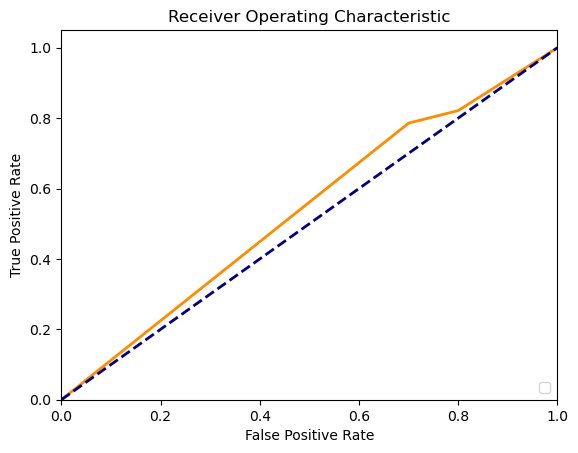

In [24]:
plt.figure()
lw = 2
plt.plot(false_pos_rate, true_pos_rate, color='darkorange', lw=lw)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [25]:
print(roc_auc_score(Y_test, pos_prob))

0.5553571428571429


## Cross-validation

In [26]:
from sklearn.model_selection import StratifiedKFold

k = 5
k_fold = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

In [27]:
smoothing_factor_option = [1, 2, 3, 4, 5, 6]
fit_prior_option = [True, False]
auc_record = {}

In [28]:
for train_indices, test_indices in k_fold.split(X, Y):
    X_train, X_test = X[train_indices], X[test_indices]
    Y_train, Y_test = Y[train_indices], Y[test_indices]
    for alpha in smoothing_factor_option:
        if alpha not in auc_record:
            auc_record[alpha] = {}
        for fit_prior in fit_prior_option:
            clf = MultinomialNB(alpha=alpha, fit_prior=fit_prior)
            clf.fit(X_train, Y_train)
            prediction_prob = clf.predict_proba(X_test)
            pos_prob = prediction_prob[:, 1]
            auc = roc_auc_score(Y_test, pos_prob)
            auc_record[alpha][fit_prior] = auc + auc_record[alpha].get(fit_prior, 0.0)

In [29]:
print('smoothing  fit prior  auc')
for smoothing, smoothing_record in auc_record.items():
    for fit_prior, auc in smoothing_record.items():
        print(f'    {smoothing}        {fit_prior}    {auc/k:.5f}')

smoothing  fit prior  auc
    1        True    0.60204
    1        False    0.60757
    2        True    0.59830
    2        False    0.59720
    3        True    0.58621
    3        False    0.59439
    4        True    0.57128
    4        False    0.57128
    5        True    0.54545
    5        False    0.55260
    6        True    0.54512
    6        False    0.54512


In [30]:
# select best hyperparameter combination (alp
clf = MultinomialNB(alpha=1.0, fit_prior=False)
clf.fit(X_train, Y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",False
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [31]:
pos_prob = clf.predict_proba(X_test)[:, 1]
print('AUC with the best model:', roc_auc_score(Y_test, pos_prob))

AUC with the best model: 0.6809090909090909
